In [1]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots, ensemble_eval
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP01'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

## Grouping runs

In [3]:
## Sort to EXP01
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()

In [4]:
## Sort within EXP01
exp_count = eval_wrapper.check_exp_count(exp_runs)
exp_options = list(exp_count.keys())
exp_options.sort()
exp_options

EXP01_no_subs_no_sw :	 6
EXP01_wi_subs_wi_sw :	 8
EXP01_no_subs_wi_sw :	 8
EXP01_wi_subs_no_sw :	 8


['EXP01_no_subs_no_sw',
 'EXP01_no_subs_wi_sw',
 'EXP01_wi_subs_no_sw',
 'EXP01_wi_subs_wi_sw']

In [5]:
names_no_subs_no_sw = [run for run in all_runs if 'EXP01_no_subs_no_sw' in run]
names_no_subs_wi_sw = [run for run in all_runs if 'EXP01_no_subs_wi_sw' in run]

names_wi_subs_no_sw = [run for run in all_runs if 'EXP01_wi_subs_no_sw' in run]
names_wi_subs_wi_sw = [run for run in all_runs if 'EXP01_wi_subs_wi_sw' in run]

## Evaluate results

In [6]:
tuple_no_subs = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_subs_no_sw,wisw_exp_names = names_no_subs_wi_sw,run_dir=all_runs_dir)
tuple_wi_subs = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_wi_subs_no_sw,wisw_exp_names = names_wi_subs_wi_sw,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_181342
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_181342
dict_keys(['1834101', '4150680', '4152450', '5608096'])
dict_keys(['1834101', '4150680', '4152450', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_190856
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_190856
dict_keys(['1834101', '4150680', '4152450', '5608096'])
dict_keys(['1834101', '4150680', '4152450', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_190938
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_190938
dict_keys(['1834101', '4150680', '4152450', '5608096'])
dict_keys(['1834101', '4150680', '4152450', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP01_no_subs_no_sw_2908_190945


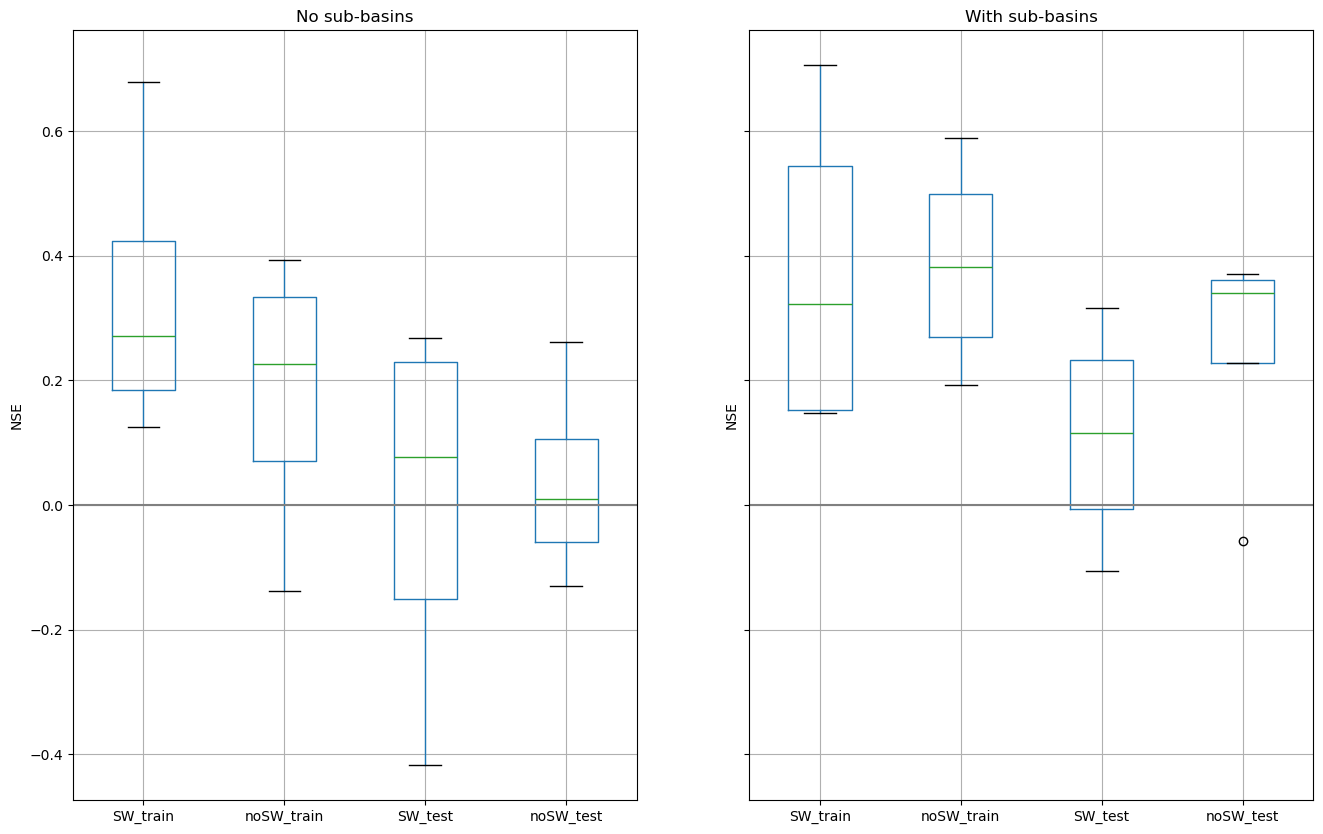

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
no_subs_nse_df = comp_plots.boxplot_from_tuple(tuple_no_subs,ax=axs[0],tuple_names=default_order,exp_name = 'No sub-basins')
wi_subs_nse_df = comp_plots.boxplot_from_tuple(tuple_wi_subs,ax=axs[1],tuple_names=default_order,exp_name = 'With sub-basins')

In [8]:
no_subs_nse_df

,1834101,4150680,4152450,5608096
SW_train,0.204706,0.339415,0.125726,0.678095
noSW_train,-0.137222,0.313269,0.140268,0.393669
SW_test,0.268103,-0.417354,-0.061986,0.217154
noSW_test,-0.129317,0.053940,-0.034959,0.260974


In [9]:
wi_subs_nse_df

,1834101,4150680,4152450,5608096
SW_train,0.147521,0.489668,0.154492,0.705952
noSW_train,0.294936,0.468556,0.193416,0.588614
SW_test,0.204301,0.026259,-0.105786,0.316766
noSW_test,0.357326,0.324188,-0.058420,0.371458
